# SDOCX Format — Stroke Geometry

The `.page` file contains all handwritten stroke data for a single page. This notebook
documents its binary layout: the page header, stroke record format, and the delta-encoding
scheme used to compress pen coordinates.

By the end, we'll reconstruct every stroke and render the full page.

In [21]:
from pathlib import Path

SAMPLE = Path("../samples/handwritten.sdocx")

In [22]:
import zipfile
import struct
import numpy as np
import matplotlib.pyplot as plt

In [23]:
DELTA_SCALE = 1 / 32.0


def hexdump(data: bytes, offset: int = 0, limit: int = 0) -> str:
    lines = []
    n = len(data) if limit == 0 else min(len(data), limit)
    for i in range(0, n, 16):
        chunk = data[i : i + 16]
        hex_part = " ".join(f"{b:02x}" for b in chunk)
        ascii_part = "".join(chr(b) if 32 <= b < 127 else "\u00b7" for b in chunk)
        lines.append(f"  {offset + i:04x}  {hex_part:<48s} {ascii_part}")
    if limit and len(data) > limit:
        lines.append(f"  ... ({len(data) - limit} more bytes)")
    return "\n".join(lines)

In [24]:
with zipfile.ZipFile(SAMPLE) as z:
    page_key = [i.filename for i in z.infolist() if i.filename.endswith(".page")][0]
    page = z.read(page_key)

print(f"{page_key} \u2014 {len(page):,} bytes")

a87cbcbc-43ce-11ee-9848-0b8ce2c9daf6.page — 4,487,877 bytes


---

## Page Header

The header occupies the first ~0x198 bytes.

| Offset | Size | Type | Content |
|--------|------|------|---------|
| `0x00` | 4 | u32 | Header size (227) |
| `0x16` | 4 | u32 | Page width |
| `0x1A` | 4 | u32 | Page height |
| `0x26` | 2 | u16 | UUID string length in chars (36) |
| `0x28` | 72 | UTF-16LE | Page UUID |
| `0x80` | 32 | 4 x f64 | Content bounding box (x_min, y_min, x_max, y_max) |
| `0x149` | 4 | u32 | Stroke count |
| `0x198` | - | - | First stroke record begins |

In [25]:
page_w = struct.unpack_from("<I", page, 0x16)[0]
page_h = struct.unpack_from("<I", page, 0x1A)[0]
print(f"Page dimensions: {page_w} \u00d7 {page_h}")

Page dimensions: 1848 × 7838


In [26]:
uuid_len = struct.unpack_from("<H", page, 0x26)[0]
page_uuid = page[0x28 : 0x28 + uuid_len * 2].decode("utf-16-le")
print(f"Page UUID: {page_uuid}")

Page UUID: a87cbcbc-43ce-11ee-9848-0b8ce2c9daf6


In [27]:
bbox = struct.unpack_from("<4d", page, 0x80)
print("Content bounding box:")
for label, val in zip(["x_min", "y_min", "x_max", "y_max"], bbox):
    print(f"  {label}: {val:.4f}")
print(f"  Size: {bbox[2] - bbox[0]:.1f} \u00d7 {bbox[3] - bbox[1]:.1f}")

Content bounding box:
  x_min: 75.8677
  y_min: 76.3188
  x_max: 1830.6403
  y_max: 2483.2087
  Size: 1754.8 × 2406.9


In [28]:
stroke_count = struct.unpack_from("<I", page, 0x149)[0]
print(f"Stroke count: {stroke_count}")

Stroke count: 2769


---

## Stroke Record Format

After the header, strokes are stored as a contiguous sequence of variable-length records.
Each record has five parts:

```
+------------+-------------+--------------+----------------+--------------+
|  Bounding  |  Metadata   |  Start Point |   Delta Data   |  Inter-Stroke|
|    Box     |             |              |   (variable)   |    Record    |
|  32 bytes  |  41 bytes   |   16 bytes   |   N bytes      |  71 bytes   |
|  4 x f64   |             |   2 x f64    |                |             |
+------------+-------------+--------------+----------------+--------------+
```

1. **Bounding box** (32 B): 4 x f64 — `x_min, y_min, x_max, y_max` in page coordinates
2. **Metadata** (41 B): Two critical fields:
   - Byte 21: **u32 data length** — total bytes of delta data (coordinates + trailing channels)
   - Byte 39: **u16 point count** — number of points in the stroke
3. **Start point** (16 B): 2 x f64 — absolute (x, y) of the first pen-down position
4. **Delta data** (variable): Encoded coordinate deltas + per-point attribute channels
5. **Inter-stroke record** (71 B): UUID and timestamp linking to the next stroke

### Walking through stroke 0

Let's inspect the first stroke record field by field.

In [29]:
off = 0x198  # first stroke

bbox = struct.unpack_from("<4d", page, off)
print("1) Bounding box (32 bytes, 4 x f64):")
print(f"   x: [{bbox[0]:.2f}, {bbox[2]:.2f}]  y: [{bbox[1]:.2f}, {bbox[3]:.2f}]")
print(f"   Size: {bbox[2] - bbox[0]:.2f} \u00d7 {bbox[3] - bbox[1]:.2f}")

1) Bounding box (32 bytes, 4 x f64):
   x: [84.43, 105.57]  y: [84.88, 146.85]
   Size: 21.14 × 61.97


In [30]:
meta = page[off + 32 : off + 73]
data_len = struct.unpack_from("<I", meta, 21)[0]
n_pts = struct.unpack_from("<H", meta, 39)[0]

print("2) Metadata (41 bytes):")
print(f"   Data length (byte 21, u32): {data_len} bytes")
print(f"   Point count (byte 39, u16): {n_pts} points")

2) Metadata (41 bytes):
   Data length (byte 21, u32): 2518 bytes
   Point count (byte 39, u16): 204 points


In [31]:
sp_off = off + 73
start_x = struct.unpack_from("<d", page, sp_off)[0]
start_y = struct.unpack_from("<d", page, sp_off + 8)[0]

print("3) Start point (16 bytes, 2 x f64):")
print(f"   ({start_x:.4f}, {start_y:.4f})")

3) Start point (16 bytes, 2 x f64):
   (87.6212, 87.8372)


In [32]:
data_off = sp_off + 16

print(f"4) Delta data ({data_len} bytes) \u2014 first 48 bytes:")
print(hexdump(page[data_off : data_off + 48], offset=data_off))

4) Delta data (2518 bytes) — first 48 bytes:
  01f1  00 80 00 80 00 80 01 80 00 80 00 80 00 80 02 80  ················
  0201  00 80 01 80 03 80 02 80 00 80 01 80 03 80 03 80  ················
  0211  03 80 03 80 00 80 03 80 03 80 03 80 03 80 05 80  ················


In [33]:
inter_off = data_off + data_len

print(f"5) Inter-stroke record (71 bytes at 0x{inter_off:04x}):")
print(hexdump(page[inter_off : inter_off + 71], offset=inter_off))

5) Inter-stroke record (71 bytes at 0x0bc7):
  0bc7  03 00 00 79 00 00 00 00 00 69 00 00 00 02 be 01  ···y·····i······
  0bd7  04 00 60 00 00 a0 0f 00 00 24 00 38 33 36 66 32  ··`······$·836f2
  0be7  64 66 30 2d 34 33 63 66 2d 31 31 65 65 2d 62 32  df0-43cf-11ee-b2
  0bf7  38 36 2d 30 66 64 64 37 66 66 34 38 63 31 64 a6  86-0fdd7ff48c1d·
  0c07  8b 66 8c cc 03 06 00                             ·f·····


---

## Delta Encoding

Stroke coordinates are **delta-encoded** using sign-magnitude byte pairs. Starting from the
start point, each subsequent point is expressed as a `(dx, dy)` offset.

### Encoding scheme

Each delta is a **2-byte pair**: `(magnitude, sign_flag)`

| Sign flag | Meaning | Formula |
|-----------|---------|----------|
| `0x00` | Positive | `+magnitude` |
| `0x80` | Negative | `-magnitude` |

The high bit (bit 7) of the sign byte acts as a sign flag. Coordinate deltas come in
**4-byte groups**: `[dx_mag, dx_sign, dy_mag, dy_sign]`.

### Scale factor

Raw delta values are scaled by **1/32** to get actual coordinate offsets:

```
actual_dx = signed_dx / 32.0
actual_dy = signed_dy / 32.0
```

### Reconstructing points

```
point[0] = start_point
point[i] = point[i-1] + (dx_i / 32, dy_i / 32)
```

### Termination

Coordinate data ends when a sign byte is encountered that is neither `0x00` nor `0x80`.
The remaining bytes in the data blob contain per-point attribute channels (pressure, tilt,
etc.) — covered in notebook 03.

### Worked example — first 5 deltas of stroke 0

In [34]:
print("Raw bytes \u2192 signed delta \u2192 scaled offset:\n")

i = data_off
for step in range(5):
    dm, ds, ym, ys = page[i], page[i + 1], page[i + 2], page[i + 3]
    sdx = dm if ds == 0x00 else -dm
    sdy = ym if ys == 0x00 else -ym
    print(
        f"  [{dm:3d} {ds:#04x} {ym:3d} {ys:#04x}]"
        f"  \u2192  ({sdx:+4d}, {sdy:+4d})"
        f"  \u2192  ({sdx * DELTA_SCALE:+.4f}, {sdy * DELTA_SCALE:+.4f})"
    )
    i += 4

Raw bytes → signed delta → scaled offset:

  [  0 0x80   0 0x80]  →  (  +0,   +0)  →  (+0.0000, +0.0000)
  [  0 0x80   1 0x80]  →  (  +0,   -1)  →  (+0.0000, -0.0312)
  [  0 0x80   0 0x80]  →  (  +0,   +0)  →  (+0.0000, +0.0000)
  [  0 0x80   2 0x80]  →  (  +0,   -2)  →  (+0.0000, -0.0625)
  [  0 0x80   1 0x80]  →  (  +0,   -1)  →  (+0.0000, -0.0312)


### Full reconstruction of stroke 0

In [35]:
x, y = start_x, start_y
points = [(x, y)]

i = data_off
while i + 3 < data_off + data_len:
    dm, ds, ym, ys = page[i], page[i + 1], page[i + 2], page[i + 3]
    if ds not in (0x00, 0x80) or ys not in (0x00, 0x80):
        break
    dx = (dm if ds == 0x00 else -dm) * DELTA_SCALE
    dy = (ym if ys == 0x00 else -ym) * DELTA_SCALE
    x += dx
    y += dy
    points.append((x, y))
    i += 4

n_coord_bytes = i - data_off

print(f"Declared:      {n_pts} points")
print(f"Reconstructed: {len(points)} points")
print(f"Coord data:    {n_coord_bytes} bytes ({n_coord_bytes // 4} delta pairs)")
print(f"Trailing data: {data_len - n_coord_bytes} bytes (attribute channels)")

Declared:      204 points
Reconstructed: 204 points
Coord data:    812 bytes (203 delta pairs)
Trailing data: 1706 bytes (attribute channels)


In [36]:
# Verify: reconstructed points should fit within the bounding box
bbox = struct.unpack_from("<4d", page, off)
xs = [p[0] for p in points]
ys = [p[1] for p in points]

print("Bounding box vs reconstructed range:\n")
print(f"  bbox x: [{bbox[0]:.2f}, {bbox[2]:.2f}]")
print(f"  recon x: [{min(xs):.2f}, {max(xs):.2f}]")
print(f"  bbox y: [{bbox[1]:.2f}, {bbox[3]:.2f}]")
print(f"  recon y: [{min(ys):.2f}, {max(ys):.2f}]")

Bounding box vs reconstructed range:

  bbox x: [84.43, 105.57]
  recon x: [84.43, 105.56]
  bbox y: [84.88, 146.85]
  recon y: [84.87, 146.87]


---

## Parsing All Strokes

Now we parse every stroke in the file by walking through the sequential record structure.

In [37]:
def parse_strokes(page):
    """Parse all strokes from a .page file.

    Returns a list of dicts with keys:
        bbox, start, points, data_blob, n_coord_bytes
    """
    stroke_count = struct.unpack_from("<I", page, 0x149)[0]
    strokes = []
    off = 0x198

    for _ in range(stroke_count):
        if off + 89 > len(page):
            break

        bbox = struct.unpack_from("<4d", page, off)
        if not all(0 < v < 10000 for v in bbox):
            break

        meta = page[off + 32 : off + 73]
        data_len = struct.unpack_from("<I", meta, 21)[0]
        n_pts = struct.unpack_from("<H", meta, 39)[0]

        sp_off = off + 73
        sx = struct.unpack_from("<d", page, sp_off)[0]
        sy = struct.unpack_from("<d", page, sp_off + 8)[0]
        data_off = sp_off + 16
        data_blob = page[data_off : data_off + data_len]

        # Decode coordinate deltas
        x, y = sx, sy
        points = [(x, y)]
        i = 0
        while i + 3 < len(data_blob):
            dm, ds, ym, ys = (
                data_blob[i],
                data_blob[i + 1],
                data_blob[i + 2],
                data_blob[i + 3],
            )
            if ds not in (0x00, 0x80) or ys not in (0x00, 0x80):
                break
            dx = (dm if ds == 0x00 else -dm) * DELTA_SCALE
            dy = (ym if ys == 0x00 else -ym) * DELTA_SCALE
            x += dx
            y += dy
            points.append((x, y))
            i += 4

        strokes.append(
            {
                "bbox": bbox,
                "start": (sx, sy),
                "points": points,
                "data_blob": data_blob,
                "n_coord_bytes": i,
                "n_pts_declared": n_pts,
            }
        )

        off = data_off + data_len + 71

    return strokes

In [38]:
strokes = parse_strokes(page)
total_pts = sum(len(s["points"]) for s in strokes)

print(f"Parsed {len(strokes)} / {stroke_count} strokes")
print(f"Total points: {total_pts:,}")

Parsed 2769 / 2769 strokes
Total points: 321,776


In [39]:
print("First 5 strokes:\n")
for i, s in enumerate(strokes[:5]):
    trailing = len(s["data_blob"]) - s["n_coord_bytes"]
    print(
        f"  [{i}] {len(s['points']):>4} pts  "
        f"start=({s['start'][0]:.1f}, {s['start'][1]:.1f})  "
        f"data={len(s['data_blob'])} B "
        f"({s['n_coord_bytes']} coord + {trailing} trailing)"
    )

First 5 strokes:

  [0]  204 pts  start=(87.6, 87.8)  data=2518 B (812 coord + 1706 trailing)
  [1]   59 pts  start=(112.5, 110.9)  data=778 B (232 coord + 546 trailing)
  [2]   77 pts  start=(113.6, 129.4)  data=994 B (304 coord + 690 trailing)
  [3]  318 pts  start=(120.4, 127.0)  data=3886 B (1268 coord + 2618 trailing)
  [4]   40 pts  start=(153.0, 119.2)  data=550 B (156 coord + 394 trailing)


---

## Rendering

With absolute coordinates reconstructed from start points + cumulative scaled deltas,
we can render the full page. No bounding-box normalization needed — the coordinates
are already in page space.

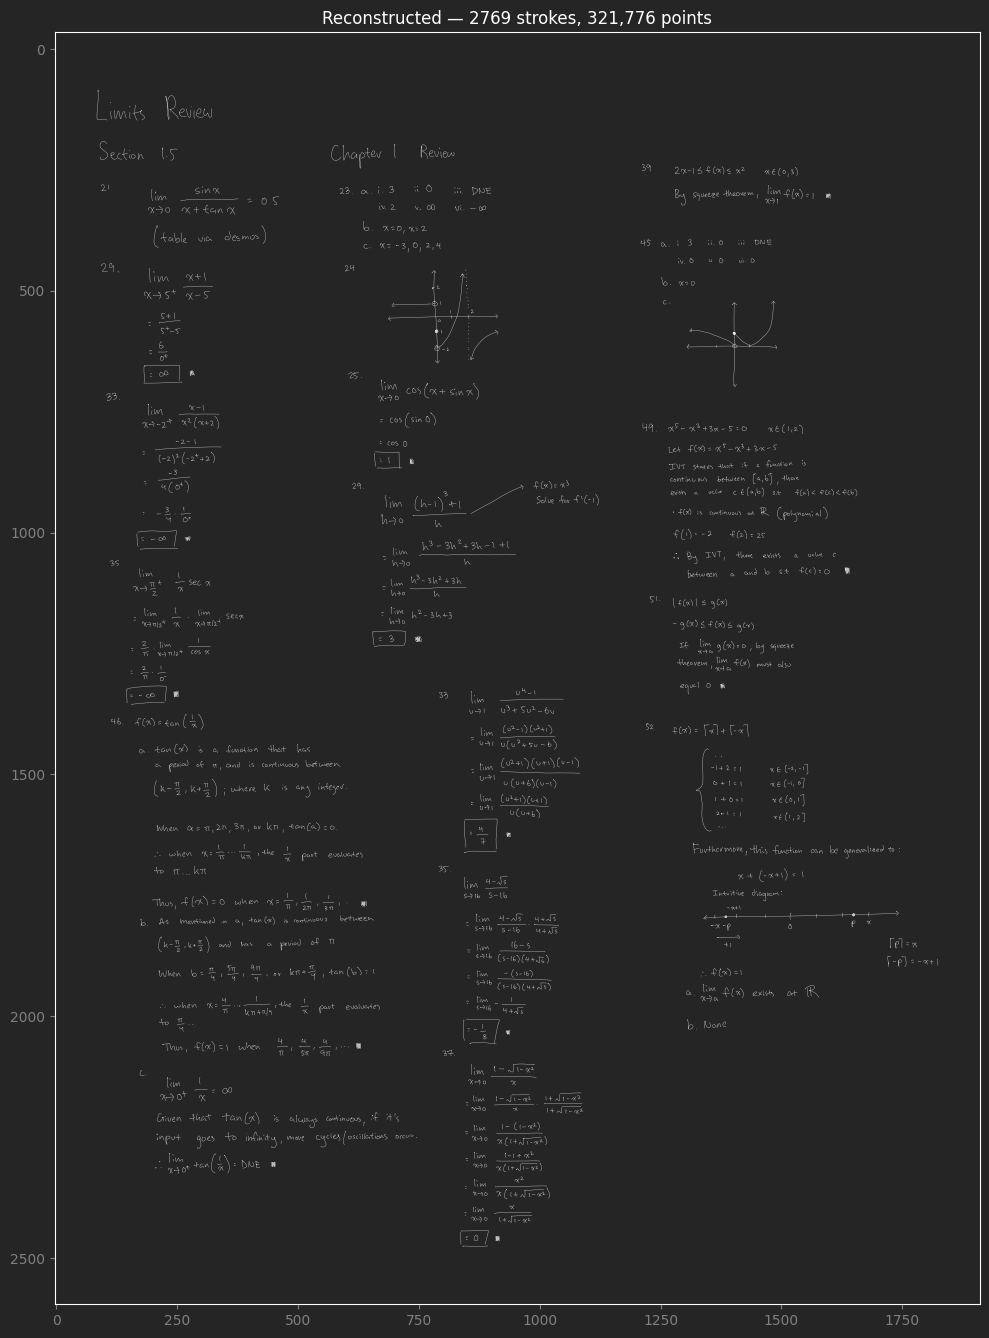

In [40]:
fig, ax = plt.subplots(figsize=(10, 14))

for s in strokes:
    if len(s["points"]) < 2:
        continue
    pts = np.array(s["points"])
    ax.plot(pts[:, 0], pts[:, 1], "w-", linewidth=0.3, alpha=0.7)

ax.set_facecolor("#252525")
fig.patch.set_facecolor("#252525")
ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_title(
    f"Reconstructed \u2014 {len(strokes)} strokes, {total_pts:,} points",
    color="white",
)
ax.tick_params(colors="gray")
plt.tight_layout()
plt.show()

---

## Summary — `.page` File Specification

### Page header

| Offset | Type | Field |
|--------|------|-------|
| `0x16` | u32 | Page width |
| `0x1A` | u32 | Page height |
| `0x26` | u16 | UUID string length (chars) |
| `0x28` | UTF-16LE | Page UUID |
| `0x80` | 4 x f64 | Content bounding box |
| `0x149` | u32 | Stroke count |

### Stroke record (sequential from `0x198`)

| Part | Size | Content |
|------|------|---------|
| Bounding box | 32 B | 4 x f64: x_min, y_min, x_max, y_max |
| Metadata | 41 B | byte 21: u32 data length; byte 39: u16 point count |
| Start point | 16 B | 2 x f64: initial (x, y) position |
| Delta data | N B | Coordinate deltas + attribute channels |
| Inter-stroke | 71 B | UUID + timestamp linking to next stroke |

### Delta encoding

- **Format**: 4-byte groups `[dx_magnitude, dx_sign, dy_magnitude, dy_sign]`
- **Sign**: `0x00` = positive, `0x80` = negative (bit 7 = sign flag)
- **Scale**: raw values x (1/32) = actual coordinate offset
- **Termination**: first sign byte that isn't `0x00` or `0x80`

### Footer

The file ends with the 26-byte ASCII marker: `"Page for SAMSUNG S-Pen SDK"`

**Next:** [03_ink.ipynb](03_ink.ipynb) decodes the trailing data — color, pen width, pressure, and tilt.